<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_07.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_07.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 07:** Training and Performance Analysis of Feedforward Neural Networks using the Backpropagation Algorithm

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will build a feedforward neural network with two hidden layers in TensorFlow/Keras and train it on the Digits dataset using the **backpropagation algorithm** with the Adam optimizer and early stopping. You will track the training process through learning curves, evaluate the trained model with a full classification report and confusion matrix, and visually inspect both correct and misclassified predictions.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Train a feedforward neural network for multiclass classification using backpropagation.
- Apply the Adam optimizer and early stopping to a training loop.
- Monitor training and validation curves to diagnose underfitting and overfitting.
- Evaluate a multiclass model using accuracy, a classification report, and a confusion matrix.
- Visually inspect correctly and incorrectly classified samples to understand model behavior.


## **Theory**

### Introduction

A feedforward neural network passes information from the input layer through one or more hidden layers to the output layer without cycles. Training uses the **backpropagation algorithm** to compute how each weight contributes to the final error, and a gradient-based optimizer then updates the weights to reduce that error. This experiment focuses on the learning process itself — how loss and accuracy evolve over epochs — which is central to all modern deep learning systems.

### Mathematical Background

If the loss function is $L(\hat{y}, y)$ and the network output is obtained by composing layers, backpropagation uses the chain rule to compute gradients such as $\partial L / \partial W$. For a layer $z = Wa + b$ with activation $a' = \phi(z)$, the gradient of the loss is propagated backward from the output layer to earlier layers:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial a'} \cdot \frac{\partial a'}{\partial z} \cdot \frac{\partial z}{\partial W}$$

For multiclass classification, the output layer uses a **softmax** activation

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j} e^{z_j}}$$

so that the outputs form a probability distribution over all classes, and the network is trained with **categorical cross-entropy loss**:

$$L = -\sum_{k=1}^{K} y_k \log(\hat{y}_k)$$

Gradient-based optimizers such as Adam then update the parameters using the computed derivatives, combining momentum with per-parameter adaptive learning rates.

### Important Concepts

The practical training loop is: initialize weights, perform forward propagation, compute the loss, backpropagate gradients, update weights, and repeat for many epochs. **Early stopping** halts training when validation performance no longer improves for a set number of epochs (patience), and restores the weights from the best epoch. In a feedforward network, hidden layers learn intermediate representations that can be more useful for classification than the raw input features alone — this is one reason deep networks generalize better than a single linear layer on many multiclass tasks.

Labels for multiclass problems are converted to **one-hot vectors** (e.g. digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]`) so they can be compared directly against the softmax output using categorical cross-entropy.

### Advantages and Applications

**Advantages**

- Feedforward networks are easy to build and are a strong baseline for classification problems.
- Backpropagation scales efficiently to networks with many layers and parameters.
- Hidden layers learn useful intermediate features automatically, without manual feature engineering.

**Disadvantages**

- Feedforward networks are less effective than specialized architectures (CNNs for images, RNNs/Transformers for sequences) because they ignore spatial or temporal structure.
- Training is sensitive to hyperparameters such as learning rate, layer sizes, and initialization.

**Applications**

Feedforward networks remain important as baselines and as building blocks inside larger systems, and are directly useful for tabular data classification, simple pattern recognition, and — as in this lab — recognizing small, low-resolution images such as handwritten digits.

```mermaid
flowchart LR
    A[Input Layer: 64 Pixels] --> B[Hidden Layer 1: ReLU]
    B --> C[Hidden Layer 2: ReLU]
    C --> D[Output Layer: Softmax]
    D --> E[Categorical Cross-Entropy Loss]
    E --> F[Backpropagation]
    F --> B
    F --> C
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Pandas
- Matplotlib
- TensorFlow 2.x / Keras
- Scikit-learn

### Starter Check

Run the first code cell (library imports and setup). If it prints `Setup complete. You can start the experiment.`, your environment is ready.

## **Dataset Description**

This experiment uses the **Digits dataset** from Scikit-learn because it is available locally (no download required), small enough for fast training, and well suited to a multiclass feedforward network example.

- **Features:** 8x8 grayscale pixel values (0-16 intensity range), flattened into 64 input features.
- **Target labels:** digits 0 through 9 (10 classes).
- **Source:** `sklearn.datasets.load_digits`.
- **Reason for selection:** compact image data that trains in seconds while still requiring a genuine multiclass, multilayer model.

## **Experimental Procedure**

Follow the steps below in order:

1. Load the Digits dataset, scale the pixel values to the [0, 1] range, and inspect a few sample images.
2. Convert labels to one-hot vectors for multiclass learning.
3. Split the data into training, validation, and test sets.
4. Build a feedforward neural network with two hidden layers and a softmax output layer.
5. Train the model with early stopping and record the learning curves.
6. Evaluate test accuracy, the classification report, and the confusion matrix.
7. Visually inspect correctly and incorrectly classified digit images.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- Why are the labels one-hot encoded instead of left as the integers 0-9?
- At what epoch did early stopping halt training, and what does the gap (or lack of gap) between training and validation accuracy tell you?
- Which digit pairs does the confusion matrix show being confused most often, and why might that make visual sense?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try changing the number of hidden units, the activation function, or the batch size, and observe how the learning curves and confusion matrix change.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress verbose TensorFlow startup logs

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [2]:
# Load the Digits dataset and scale pixel values

digits = load_digits()
X = digits.data.astype("float32") / 16.0
y = digits.target
y_one_hot = tf.keras.utils.to_categorical(y, num_classes=10)

print("Shape:", X.shape)
print("Class counts:\n", np.bincount(y))
print("Pixel value range after scaling: [{:.2f}, {:.2f}]".format(X.min(), X.max()))

Shape: (1797, 64)
Class counts:
 [178 182 177 183 181 182 181 179 174 180]
Pixel value range after scaling: [0.00, 1.00]


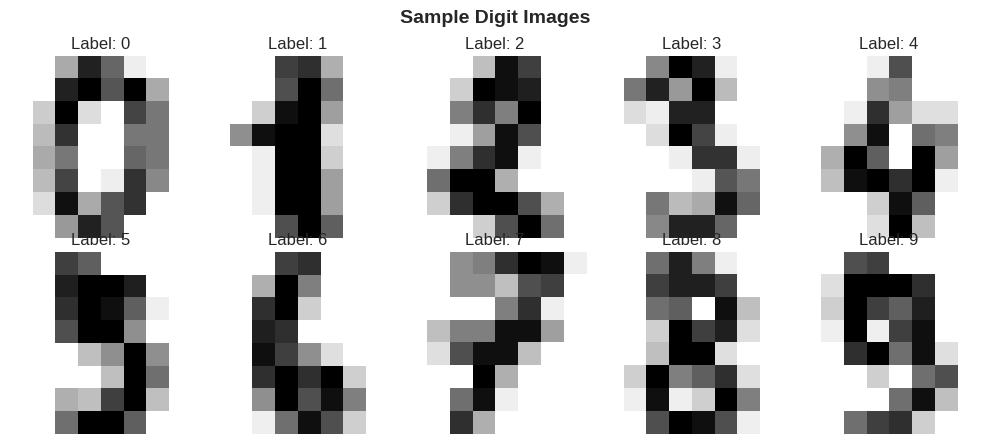

In [3]:
# Visualize Sample Digit Images

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")

plt.suptitle("Sample Digit Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
# Train / Validation / Test Split

X_train_full, X_test, y_train_full, y_test, y_train_full_int, y_test_int = train_test_split(
    X, y_one_hot, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_train, X_val, y_train, y_val, y_train_int, y_val_int = train_test_split(
    X_train_full, y_train_full, y_train_full_int,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full_int,
)

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

Train shape     : (1149, 64)
Validation shape: (288, 64)
Test shape      : (360, 64)


In [5]:
# Build the Feedforward Neural Network

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the Network with Early Stopping (Backpropagation)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)],
)

print(f"Training finished after {len(history.history['loss'])} epochs.")

Training finished after 50 epochs.


In [7]:
# Evaluate on the Test Set

test_probabilities = model.predict(X_test, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_true = np.argmax(y_test, axis=1)

test_accuracy = accuracy_score(test_true, test_predictions)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(classification_report(test_true, test_predictions, target_names=[str(i) for i in range(10)]))

Test Accuracy : 0.9806
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.94      0.94      0.94        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.94      0.94        35
           9       0.97      0.97      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



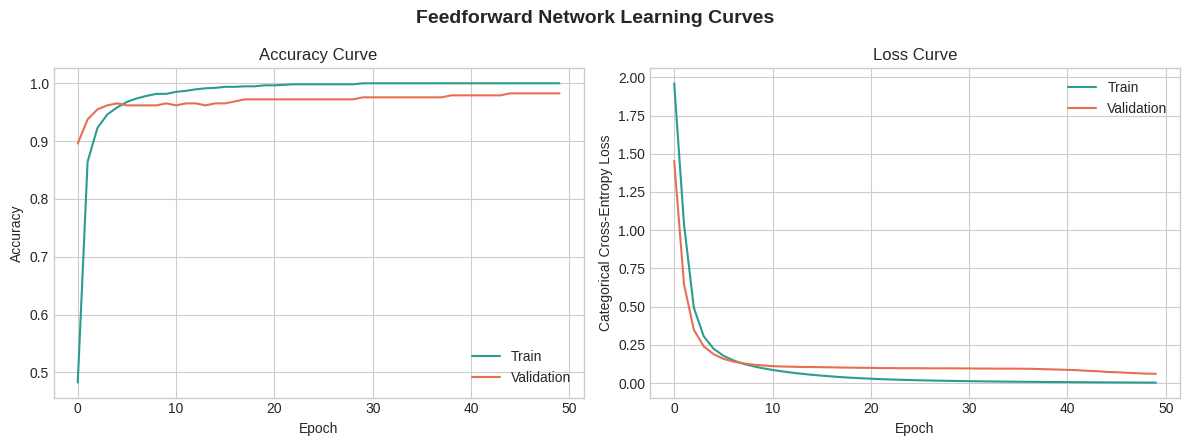

In [8]:
# Training vs Validation Accuracy and Loss Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0].set_title("Accuracy Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train", color="#2a9d8f")
axes[1].plot(history.history["val_loss"], label="Validation", color="#e76f51")
axes[1].set_title("Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Categorical Cross-Entropy Loss")
axes[1].legend()

plt.suptitle("Feedforward Network Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

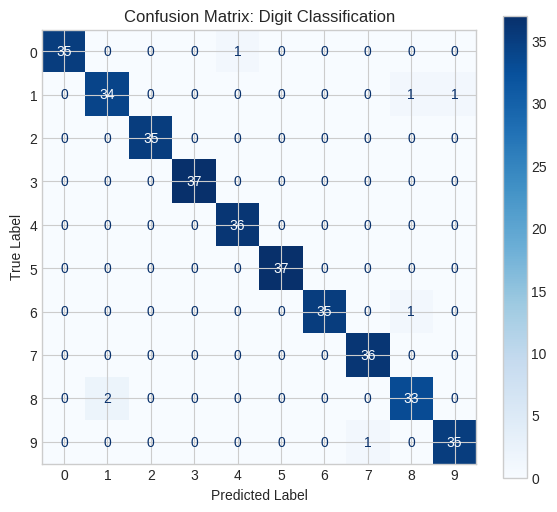

In [9]:
# Confusion Matrix

cm = confusion_matrix(test_true, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[str(i) for i in range(10)]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")

plt.title("Confusion Matrix: Digit Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

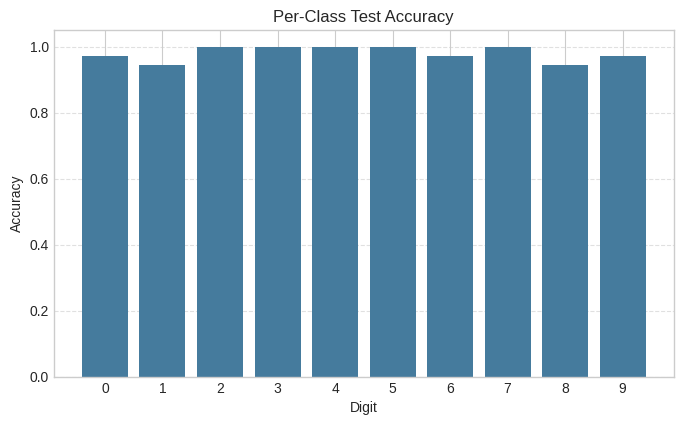

In [10]:
# Per-Class Accuracy

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 4.5))
plt.bar(range(10), per_class_accuracy, color="#457b9d")

plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.title("Per-Class Test Accuracy")
plt.xticks(range(10))
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Correctly classified : 353 / 360
Misclassified         : 7 / 360


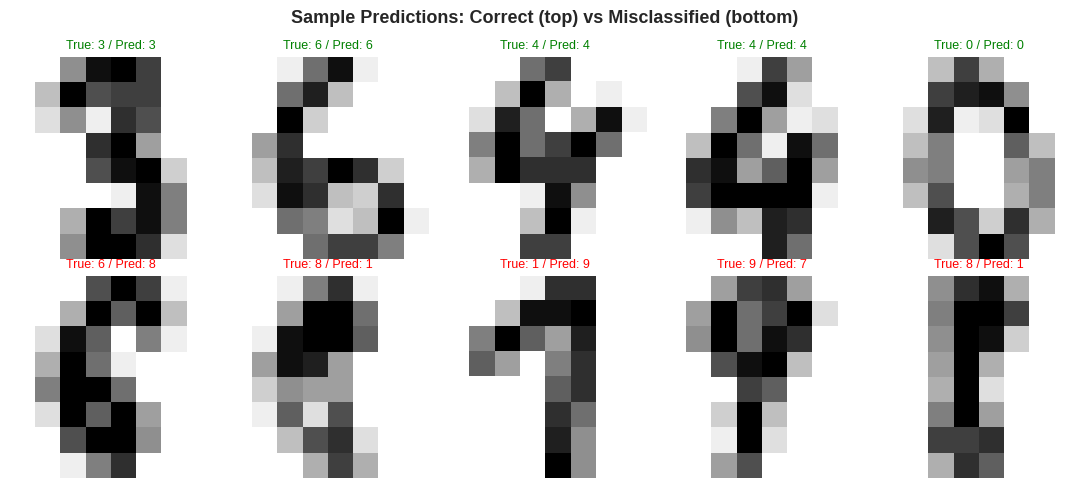

In [11]:
# Visualize Correct and Misclassified Predictions

misclassified = np.where(test_predictions != test_true)[0]
correct = np.where(test_predictions == test_true)[0]

print(f"Correctly classified : {len(correct)} / {len(test_true)}")
print(f"Misclassified         : {len(misclassified)} / {len(test_true)}")

sample_correct = np.random.choice(correct, size=5, replace=False)
sample_wrong = misclassified[:5] if len(misclassified) >= 5 else misclassified

fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for ax, idx in zip(axes[0], sample_correct):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"True: {test_true[idx]} / Pred: {test_predictions[idx]}", fontsize=9, color="green")
    ax.axis("off")

for ax, idx in zip(axes[1], sample_wrong):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"True: {test_true[idx]} / Pred: {test_predictions[idx]}", fontsize=9, color="red")
    ax.axis("off")

for ax in axes[1][len(sample_wrong):]:
    ax.axis("off")

axes[0, 0].set_ylabel("Correct", fontsize=11)
axes[1, 0].set_ylabel("Misclassified", fontsize=11)

plt.suptitle("Sample Predictions: Correct (top) vs Misclassified (bottom)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## **Expected Output**

After running all cells, the notebook should display:

- Dataset shape, class counts, and confirmation of the pixel scaling range.
- A grid of sample digit images with their labels.
- Train/validation/test split shapes.
- The network summary and the epoch at which early stopping triggered.
- Test accuracy and a full classification report across all 10 digit classes.
- Accuracy and loss learning curves.
- A confusion matrix and a per-class accuracy bar chart.
- A grid of correctly classified and misclassified sample digit images.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Performance Evaluation**

The most relevant metrics are training accuracy, validation accuracy, test accuracy, and the shapes of the learning curves. A small, stable gap between training and validation performance usually indicates good generalization, while a widening gap suggests overfitting. The confusion matrix and per-class accuracy chart reveal whether errors are spread evenly or concentrated on specific, visually similar digit pairs.

## **Discussion**

Backpropagation is the mechanism that makes multi-layer learning possible: it efficiently computes how every weight in the network contributed to the final error, so gradient descent can update all layers at once. The network learns intermediate representations automatically, which is why it performs better than a single linear classifier on many multiclass tasks. The downside is that training requires careful tuning of hyperparameters such as learning rate, layer sizes, and the early-stopping patience, and the model can still overfit a small dataset if the network is too large relative to the amount of training data.

## **Viva Questions**

1. **Q:** What is a feedforward neural network?  
   **A:** A network where data flows from the input layer to the output layer through one or more hidden layers without cycles.

2. **Q:** What does backpropagation compute?  
   **A:** The gradients of the loss with respect to every weight in the network, using the chain rule.

3. **Q:** Why is the Adam optimizer popular?  
   **A:** It combines momentum with adaptive, per-parameter learning rates, which usually leads to fast and stable convergence.

4. **Q:** What is the purpose of an activation function such as ReLU?  
   **A:** To introduce non-linearity, allowing the network to model complex relationships instead of only linear ones.

5. **Q:** Why is one-hot encoding used for the labels here?  
   **A:** Because the output layer uses softmax with categorical cross-entropy, which compares a probability distribution against a one-hot target vector.

6. **Q:** What is early stopping, and why use it?  
   **A:** Stopping training when validation performance stops improving for a set number of epochs, to prevent overfitting and save training time.

7. **Q:** Why is the Digits dataset useful for this experiment?  
   **A:** It is small, requires no download, and is well suited to demonstrating multiclass feedforward training quickly.

8. **Q:** What is the role of the hidden layers?  
   **A:** To learn intermediate feature representations from the raw pixel input that make the classes easier to separate.

9. **Q:** What does a rising validation loss alongside falling training loss indicate?  
   **A:** Overfitting — the model is fitting the training data at the expense of generalization.

10. **Q:** Why is a confusion matrix useful beyond overall accuracy?  
    **A:** It shows exactly which classes are being confused with each other, which a single accuracy number cannot reveal.

## **Exercises**

Complete the following tasks after running the notebook:

1. Change the number of hidden units (e.g. 64/32 instead of 128/64) and compare the test accuracy.
2. Try `tanh` activation instead of `relu` in the hidden layers and observe the effect on convergence speed.
3. Add a `Dropout` layer after each hidden layer and check whether validation loss improves or the train/validation gap narrows.
4. Train the network without early stopping (set a high fixed number of epochs) and compare the resulting learning curves.
5. Replace the Digits dataset with another multiclass dataset from Scikit-learn (e.g. `load_wine`) and adapt the input/output layer sizes accordingly.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Objective and theory summary in your own words.
- All important code outputs, including the classification report.
- The learning curves, confusion matrix, per-class accuracy chart, and sample prediction images.
- Short discussion of which digits were most often confused and why.
- Answers to assigned viva questions.
- Completed exercises.

**Reminder:** A good lab report should not only show screenshots. It should explain what the outputs mean.
